In [17]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
import pandas as pd

In [18]:
df = pd.read_csv('/content/HousingData.csv')
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [19]:
df.isna().sum()

,0
CRIM,20
ZN,20
INDUS,20
CHAS,20
NOX,0
RM,0
AGE,20
DIS,0
RAD,0
TAX,0


In [20]:
df = df.fillna(df.mean())
df.isna().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


In [21]:
#split features and target
X = df.drop('MEDV', axis=1)
y = df['MEDV']

(X_train, X_test, y_train, y_test) = train_test_split(X,y, test_size=0.2, random_state=42)

In [22]:
#normalize, feature scaling

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [23]:
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense

#build the nueral network
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(1) # by default activation is linear
])

# # MSE loss for regression; MAE as human-readable metric
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,121 (20.00 KB)

 Trainable params: 5,121 (20.00 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
# validation is used for evaluation after each epoch - used to detect overfitting, early stopping
model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2, verbose=1)

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 597.0783 - mae: 22.5703 - val_loss: 517.5601 - val_mae: 21.2417
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 553.0839 - mae: 21.5747 - val_loss: 474.5459 - val_mae: 20.2213
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 500.9465 - mae: 20.3679 - val_loss: 421.0235 - val_mae: 18.8754
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 435.9207 - mae: 18.7221 - val_loss: 349.9492 - val_mae: 16.9428
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 348.9071 - mae: 16.4484 - val_loss: 264.7686 - val_mae: 14.4420
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 255.1759 - mae: 13.6159 - val_loss: 176.3522 - val_mae: 11.3670
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 166.5703 - mae: 10.4305 - val_loss: 106.2543 - val_mae: 8.1896
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 106.1772 - mae: 8.0488 - val_loss: 65.3394 - val_mae: 5.9671
Epoch 9/100
1

In [25]:
#evaluate
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
rmse = np.sqrt(test_loss)
print(f"\nTest MSE  : {test_loss:.2f}")
print(f"Test MAE  : {test_mae:.2f}  (avg error ≈ ${test_mae*1000:.0f})")



Test MSE  : 12.94
Test MAE  : 2.40  (avg error ≈ $2404)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


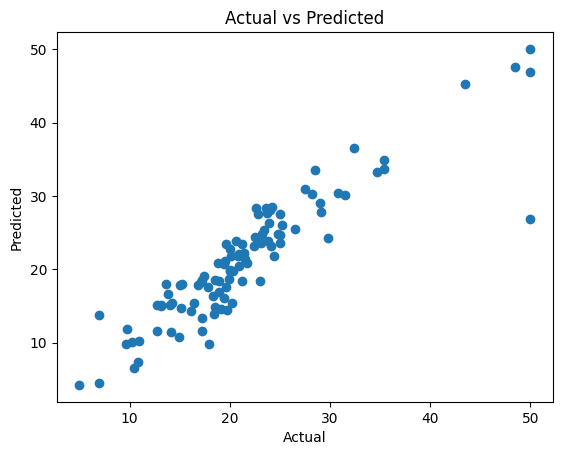

In [26]:
#plot graph
# Predictions
y_pred = model.predict(X_test)
# Scatter Plot
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [27]:
# ----- 7. Sample Predictions -----
predictions = model.predict(X_test[:5]).flatten()
for i in range(5):
    print(f"Predicted: ${predictions[i]*1000:.0f}  |  Actual: ${y_test.iloc[i]*1000:.0f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Predicted: $28326  |  Actual: $23600
Predicted: $36527  |  Actual: $32400
Predicted: $18011  |  Actual: $13600
Predicted: $27553  |  Actual: $22800
Predicted: $14303  |  Actual: $16100
